Dídac Costa Gargallo - u252353

Senyals i Sistemes I

22/11

**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [77]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [78]:
# Definim un altre cop les funcions synthesize i envelope
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y


def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    
    # Rectificació de valor absolut (full-wave rectifier)
    x_rectified = np.abs(x)

    # Coeficients del filtre de mitjana
    b = np.ones(N) / N

    # Aplicació del filtre FIR amb mode 'same'
    y = np.convolve(x_rectified, b, mode='same')

    return y

# Carreguem el senyal de referència
reference, fs = load_audio('audio/reference.wav')

# Paràmetres del senyal sintetitzat
f0 = 915.16                     # freqüència fonamental
phi = -np.pi / 2                # fase inicial
A_ref = 0.13                    # amplitud de referència
duration = len(reference) / fs # duració basada en el senyal de referència
t = np.linspace(0, duration, len(reference))  # vector de temps

# Amplituds relatives mesurades (fins al 7è harmònic)
Ak = [1, 0.6, 0.06, 0.03, 0.03, 0.007, 0.003]

# Generem el senyal sintetitzat
synth = synthesize(f0, phi, Ak, t)

# Calculem l’envolvent del senyal de referència
N_env = 40
env = envelope(reference, N_env)

# Apliquem l’envolvent al senyal sintetitzat
synth *= env

# Normalització del senyal
synth = A_ref * synth / np.max(np.abs(synth))

1.2 Plot both reference and synthesised signal.

In [79]:
# Representació conjunta
plot_signals([reference, synth], fs, t_start=0, t_end=duration,
             name=['Senyal de referència', 'Senyal sintetitzat'])

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

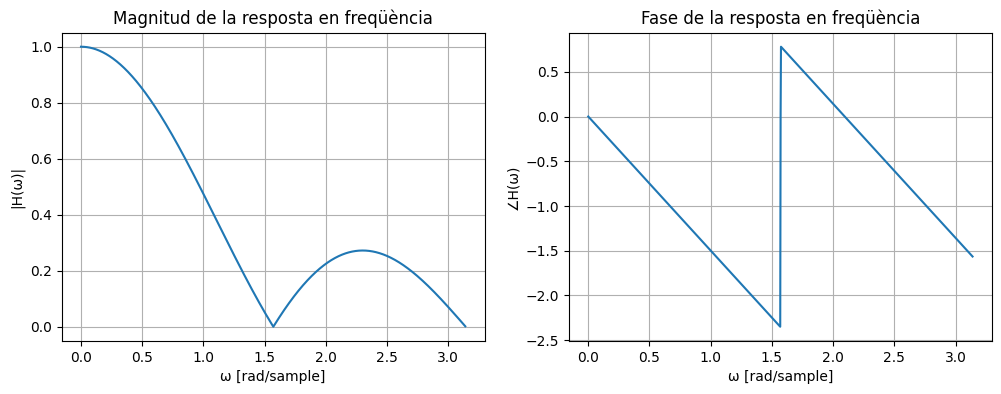

In [80]:
# Definim un filtre de mitjana de 4 punts
N = 4
b = np.ones(N) / N   # coeficients del filtre FIR

# Calculem la resposta en freqüència
w, h = signal.freqz(b, 1, worN=1024)

# Magnitud (|H(ω)|)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(w, np.abs(h))
plt.title('Magnitud de la resposta en freqüència')
plt.xlabel('ω [rad/sample]')
plt.ylabel('|H(ω)|')
plt.grid()

# Fase (∠H(ω))
plt.subplot(1,2,2)
plt.plot(w, np.angle(h))
plt.title('Fase de la resposta en freqüència')
plt.xlabel('ω [rad/sample]')
plt.ylabel('∠H(ω)')
plt.grid()
plt.show()


For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



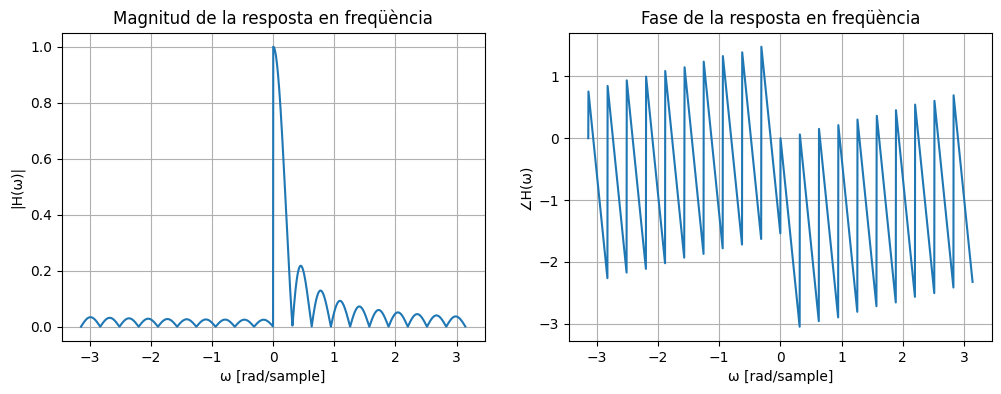

In [81]:
# Definim el filtre de mitjana de N_env punts (el mateix que a l’envolvent)
b = np.ones(N_env) / N_env   # coeficients del filtre FIR

# Calculem la resposta en freqüència
w, H = signal.freqz(b, 1, worN=2048)   

# Convertim w a l’interval [-π, π]
w_shifted = np.linspace(-np.pi, np.pi, len(w))
H_shifted = np.fft.fftshift(H)

# Funció per representar magnitud i fase
def plot_frequency_response(w, H):
    plt.figure(figsize=(12,4))
    
    # Magnitud
    plt.subplot(1,2,1)
    plt.plot(w, np.abs(H))
    plt.title('Magnitud de la resposta en freqüència')
    plt.xlabel('ω [rad/sample]')
    plt.ylabel('|H(ω)|')
    plt.grid()
    
    # Fase
    plt.subplot(1,2,2)
    plt.plot(w, np.angle(H))
    plt.title('Fase de la resposta en freqüència')
    plt.xlabel('ω [rad/sample]')
    plt.ylabel('∠H(ω)')
    plt.grid()
    
    plt.show()

# Cridem la funció de representació
plot_frequency_response(w_shifted, H_shifted)



2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

El filtre de mitjana de 4 punts té una resposta en freqüència més ampla, és a dir, deixa passar components fins a freqüències mitjanes, amb una transició més suau entre passa-baixes i atenuació. En canvi, el meu filtre de mitjana, que utilitza 40 punts per la sortida, és molt més selectiu, actua com un passa-baixes més estricte, atenuant fortament les freqüències mitjanes i altes. La magnitud cau més ràpid i la banda útil és molt més estreta.

Comparant els gràfics dels dos filtres es pot observar que quan augmentem 𝑁 la banda de magnituds útils es fa més estreta, la transició entre passa-baixes i atenuació és més abrupta i el filtre suavitza més el senyal, eliminant components ràpides amb més eficàcia.

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [82]:
def add_interference(x, fs):
    # Vector de mostres
    n = np.arange(len(x))
    
    # Freqüència de la interferència: W = 0.5π → f = fs / 4
    f_interf = fs / 4
    
    # Generem una sinusoide amb amplitud 0.2
    interference = 0.2 * np.cos(2 * np.pi * f_interf * n / fs)
    
    # Afegim la interferència al senyal original
    x_interf = x + interference
    
    return x_interf


In [83]:
x_interf = add_interference(reference, fs)

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [84]:
# Afegim interferència al senyal de referència
x_interf = add_interference(reference, fs)

# Representem el senyal original i el senyal amb interferència
plot_signals([reference, x_interf], fs, t_start=0, t_end=len(reference)/fs,
             name=['Senyal de referència', 'Senyal amb interferència'])

# Escoltem el senyal amb interferència
ipd.Audio(x_interf, rate=fs)

3.3 Compare the spectrograms of the reference signal and the interference signal. 

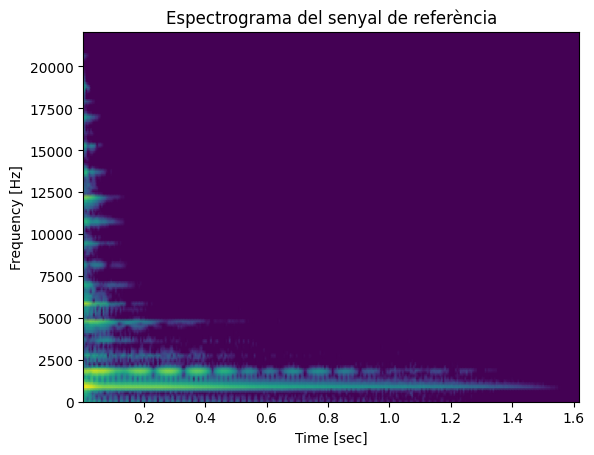

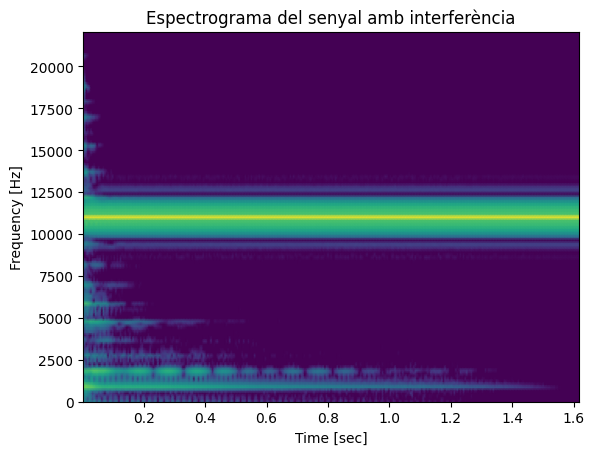

In [85]:
# Càlcul de l’espectrograma del senyal de referència
f_ref, t_ref, S_ref = signal.spectrogram(reference, fs)

# Càlcul de l’espectrograma del senyal amb interferència
f_int, t_int, S_int = signal.spectrogram(x_interf, fs)

# Representem l’espectrograma del senyal de referència
plot_spectrogram(f_ref, t_ref, S_ref)
plt.title('Espectrograma del senyal de referència')
plt.show()

# Representem l’espectrograma del senyal amb interferència
plot_spectrogram(f_int, t_int, S_int)
plt.title('Espectrograma del senyal amb interferència')
plt.show()


3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 11025 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [86]:
def remove_interference(x, fs):
  """Applies nulling filter to remove an interference at 1000 Hz

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  # Freqüència a anul·lar (44100/4 Hz)
  fn = 11025

  # Freqüència normalitzada en radians
  Wn = 2 * np.pi * fn / fs

  # Coeficients del filtre FIR de 3 punts
  b = np.array([1, -2 * np.cos(Wn), 1])

  # Aplicació del filtre FIR
  y = np.convolve(x, b, mode='same')

  return y

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

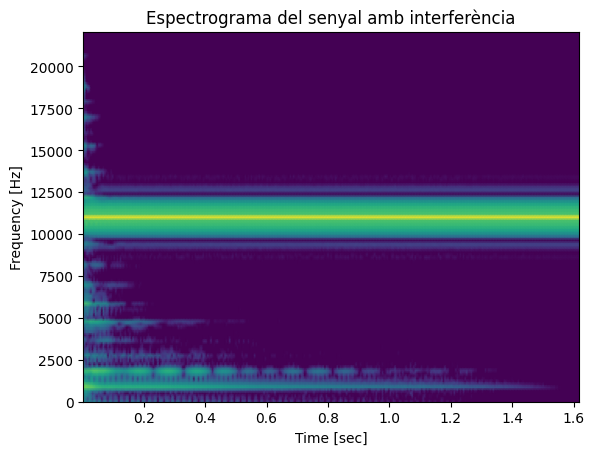

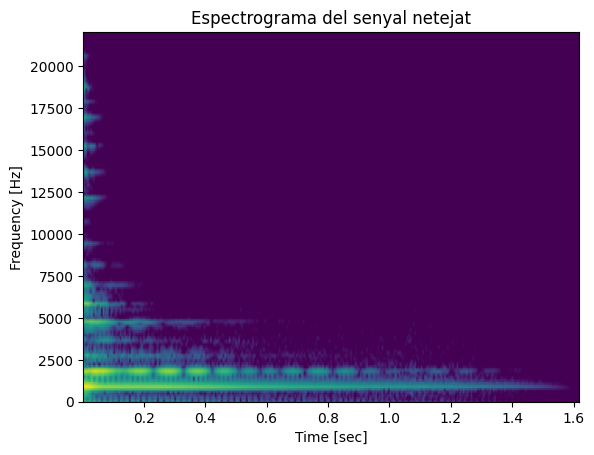

In [87]:
# Apliquem el filtre anul·lador al senyal amb interferència
x_clean = remove_interference(x_interf, fs)

# Càlcul de l’espectrograma del senyal corromput
f_int, t_int, S_int = signal.spectrogram(x_interf, fs)

# Càlcul de l’espectrograma del senyal netejat
f_clean, t_clean, S_clean = signal.spectrogram(x_clean, fs)

# Representem l’espectrograma del senyal amb interferència
plot_spectrogram(f_int, t_int, S_int)
plt.title('Espectrograma del senyal amb interferència')
plt.show()

# Representem l’espectrograma del senyal netejat
plot_spectrogram(f_clean, t_clean, S_clean)
plt.title('Espectrograma del senyal netejat')
plt.show()


El senyal amb interferència mostra una component espectral fixa i intensa a 11025 Hz, que es manté constant al llarg del temps. Aquesta component no forma part del senyal original i pot interferir en l’anàlisi o en la percepció del contingut útil.

Després d’aplicar el filtre anul·lador, aquesta component desapareix completament de l’espectrograma. El senyal netejat conserva la resta de components espectrals, però sense la presència de la interferència. Això confirma que el filtre FIR de 3 coeficients ha estat eficaç per eliminar selectivament la freqüència no desitjada.